# <h1 style= 'color:#1B3A6B;'> 1. PROYECTO </h1>

## <span style='color:#2E86AB;'> RUSTY BARGAIN: PREDICCIÓN DEL VALOR DE MERCADO DE AUTOS USADOS </span>


El servicio de venta de autos usados **Rusty Bargain** está desarrollando una aplicación para atraer nuevos clientes. Gracias a esa app, los usuarios pueden averiguar rápidamente el valor de mercado de su coche. Se cuenta con acceso al historial de datos: especificaciones técnicas, versiones de equipamiento y precios de vehículos.



---
# <span style='color:#1B3A6B;'> 2. OBJETIVOS </span>
---

## <span style='color:#2E86AB;'> 2.1. General </span>

* Construir un modelo que determine el valor de mercado de un auto usado a partir de sus características.
  
## <span style='color:#2E86AB;'> 2.2. Específico </span>

* Entrenar distintos modelos de regresión para predecir el precio de autos.
* Evaluar y comparar los modelos considerando tres criterios clave para la empresa.

     1. **Calidad de la predicción** (medida con la raíz del error cuadrático medio, RECM)
     2. **Velocidad de predicción** (tiempo de inferencia)
     3. **Tiempo requerido para el entrenamiento**
* Seleccionar el modelo que ofrezca el mejor equilibrio entre estas tres dimensiones.

---
# <span style='color:#1B3A6B;'> 3. DESCRIPCIÓN DE LOS DATOS </span>
---

El dataset contiene la siguiente información:

**Características (features)**

- `DateCrawled` — fecha en la que se descargó el perfil de la base de datos
- `VehicleType` — tipo de carrocería del vehículo
- `RegistrationYear` — año de matriculación del vehículo
- `Gearbox` — tipo de caja de cambios
- `Power` — potencia (CV)
- `Model` — modelo del vehículo
- `Mileage` — kilometraje (medido en km)
- `RegistrationMonth` — mes de matriculación del vehículo
- `FuelType` — tipo de combustible
- `Brand` — marca del vehículo
- `NotRepaired` — vehículo con o sin reparación
- `DateCreated` — fecha de creación del perfil
- `NumberOfPictures` — número de fotos del vehículo
- `PostalCode` — código postal del propietario
- `LastSeen` — fecha de la última actividad del usuario

**Objetivo (target):**
- `Price` — precio (en euros)



---
# <span style='color:#1B3A6B;'> 4. PREPARACIÓN DE DATOS </span>
---

## <span style='color:#2E86AB;'>4.1. Importación de Librerías </span>


In [1]:
# Librerías generales

import numpy as np
import pandas as pd
import time
import warnings

warnings.filterwarnings('ignore')        # Maneja advertencias de python

# Visualización 
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y validación
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import mean_squared_error

# Prueba de cordura
from sklearn.dummy import DummyRegressor

# Modelos
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Modelos de potenciación de gradiente 
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

print('Librerías importadas')

Librerías importadas


## <span style='color:#2E86AB;'> 4.2. Cargar datos </span>

In [2]:
# Cargar los datos y ver primeras filas

df_original = pd.read_csv("/Users/Loarte Juan/Documents/Dataset_Project_15/car_data.csv")

df = df_original.copy()

print('========10 FILAS ALEATORIAS========')
df.sample(10)

========10 FILAS ALEATORIAS========


,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
161747,21/03/2016 18:55,1290,small,2003,manual,60,fiesta,100000,12,petrol,ford,no,21/03/2016 00:00,0,52349,28/03/2016 16:17
315074,30/03/2016 18:38,9990,sedan,2006,manual,129,1er,60000,2,petrol,bmw,no,30/03/2016 00:00,0,91634,07/04/2016 09:44
131240,07/03/2016 16:38,1050,NaN,2018,manual,50,arosa,150000,8,NaN,seat,no,07/03/2016 00:00,0,12157,21/03/2016 04:16
322886,03/04/2016 19:55,3950,small,2009,manual,67,i_reihe,90000,6,petrol,hyundai,no,03/04/2016 00:00,0,54295,05/04/2016 20:45
332825,03/04/2016 14:42,2100,small,2005,auto,50,c2,150000,1,gasoline,citroen,NaN,03/04/2016 00:00,0,31224,05/04/2016 13:18
317755,12/03/2016 10:58,1990,NaN,2001,manual,0,corolla,150000,2,petrol,toyota,NaN,12/03/2016 00:00,0,4177,06/04/2016 02:46
205165,11/03/2016 10:50,5500,convertible,2008,manual,69,tigra,100000,8,gasoline,opel,NaN,11/03/2016 00:00,0,26441,31/03/2016 07:42
308271,15/03/2016 23:47,15165,wagon,2010,auto,184,3er,90000,4,gasoline,bmw,no,15/03/2016 00:00,0,74613,17/03/2016 23:45
118099,28/03/2016 14:06,11200,convertible,2003,auto,231,3er,150000,12,petrol,bmw,NaN,28/03/2016 00:00,0,56566,06/04/2016 10:44
48493,03/04/2016 19:48,1200,bus,1999,manual,175,voyager,150000,7,petrol,chrysler,NaN,03/04/2016 00:00,0,28307,05/04/2016 20:45


## <span style='color:#2E86AB;'>4.3. Exploración Inicial de Datos </span>

In [3]:
# Exploración EDA

print('================INFORMACIÓN GENERAL DEL DATASET================')
print(df.info())
print('--' * 40)

print()
print('========================FILAS Y COLUMNA=====================')
print(f'Filas   : {df.shape[0]}')
print(f"Columnas: {df.shape[1]}")

print()
print('====================DESCRIPCIÓN DEL DATASET=================')
print(df.describe())


================INFORMACIÓN GENERAL DEL DATASET================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Mileage            354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  NotRepaired        283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  Last

## <span style='color:#2E86AB;'>4.4. Verificar Valores Ausentes y Duplicados </span>

In [4]:
# Valores ausentes

print('=======VALORES AUSENTES=======')
print(df.isnull().sum())

print()
print('=====VALORES DUPLICADOS=====')
print(df.duplicated().sum())


=======VALORES AUSENTES=======
DateCrawled              0
Price                    0
VehicleType          37490
RegistrationYear         0
Gearbox              19833
Power                    0
Model                19705
Mileage                  0
RegistrationMonth        0
FuelType             32895
Brand                    0
NotRepaired          71154
DateCreated              0
NumberOfPictures         0
PostalCode               0
LastSeen                 0
dtype: int64

=====VALORES DUPLICADOS=====
262


## <span style='color:#2E86AB;'> 4.5. Revisión y Limpieza de Datos </span>

En esta sección se identifica lo siguiente:

* Tratar valores ausentes en las columnas categóricas (VehicleType, Gearbox, Model, FuelType, NotRepaired).

* Revisión de valores atípicos o poco realistas por ejemplo la columna Price igual a 0, RegistrationYear fuera de un rango razonable, o Power con valores igual a 0 o extremadamente alto.

* Eliminar columnas irrelevantes para la predicción del precio (fechas de rastreo, número de fotos, código postal).

In [5]:
# Eliminación de columnas irrelevantes para el modelo

columns_to_drop = ['DateCrawled', 'DateCreated', 'NumberOfPictures', 'PostalCode', 'LastSeen']

df = df.drop(columns=[c for c in columns_to_drop if c in df.columns])

df.head()

,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired
0,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN
1,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes
2,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN
3,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no
4,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no


In [6]:
# Tratamiento de valores ausentes en variables categóricas 

categorical_cols = ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'NotRepaired']

for cols in categorical_cols:
    if cols in df.columns:
        df[cols] = df[cols].fillna('unknown')

print('Valores Ausentes')
print(df.isna().sum())

print('--' * 40)

# Ver cuántos duplicados hay actualmente y cómo lucen después de eliminar las columnas innecesarias
duplicados = df[df.duplicated(keep=False)]

print(f'Total de filas duplicadas actualmente: {df.duplicated().sum()}')
duplicados.sort_values(by=list(df.columns)).head(20)

Valores Ausentes
Price                0
VehicleType          0
RegistrationYear     0
Gearbox              0
Power                0
Model                0
Mileage              0
RegistrationMonth    0
FuelType             0
Brand                0
NotRepaired          0
dtype: int64
--------------------------------------------------------------------------------
Total de filas duplicadas actualmente: 27543


,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired
199835,0,bus,1994,manual,0,transporter,150000,1,gasoline,volkswagen,unknown
283241,0,bus,1994,manual,0,transporter,150000,1,gasoline,volkswagen,unknown
82258,0,bus,1994,manual,68,transporter,150000,5,gasoline,volkswagen,unknown
254668,0,bus,1994,manual,68,transporter,150000,5,gasoline,volkswagen,unknown
107497,0,bus,1995,manual,102,transporter,150000,5,gasoline,volkswagen,no
259813,0,bus,1995,manual,102,transporter,150000,5,gasoline,volkswagen,no
50342,0,bus,1996,auto,110,transporter,150000,0,petrol,volkswagen,no
64344,0,bus,1996,auto,110,transporter,150000,0,petrol,volkswagen,no
233600,0,bus,1996,auto,110,transporter,150000,0,petrol,volkswagen,no
234704,0,bus,1996,auto,110,transporter,150000,0,petrol,volkswagen,no


In [7]:
# Eliminar valores duplicados 

print('Filas antes de eliminar duplicados:', df.shape[0])

df = df.drop_duplicates().reset_index(drop=True)
print('Filas después de eliminar duplicados:', df.shape[0])

Filas antes de eliminar duplicados: 354369
Filas después de eliminar duplicados: 326826


In [8]:
# Filtrado de valores atípicos / poco realistas

df = df[(df['Price'] > 100) & (df['Price'] < 20000)]
df = df[(df['RegistrationYear'] >= 1990) & (df['RegistrationYear'] <= 2019)]
df = df[(df['Power'] > 0) & (df['Power'] < 500)]

df = df.reset_index(drop = True)

print('Filtrado de valores atípicos')
print(f'Filas   : {df.shape[0]}')
print(f'Columnas: {df.shape[1]}')



Filtrado de valores atípicos
Filas   : 274543
Columnas: 11


In [9]:
# Codificación de variables categóricas (Ordinal Encoding, adecuado para modelos basados en árboles)

cat_features = df.select_dtypes(include='object').columns.tolist()

encoder = OrdinalEncoder()
df[cat_features] = encoder.fit_transform(df[cat_features])


df.columns = [col.lower() for col in df.columns]    # Transformar minúsculas las columnas
df.head()

,price,vehicletype,registrationyear,gearbox,power,model,mileage,registrationmonth,fueltype,brand,notrepaired
0,18300,2.0,2011,1.0,190,226.0,125000,5,2.0,1.0,2.0
1,9800,6.0,2004,0.0,163,117.0,125000,8,2.0,14.0,1.0
2,1500,5.0,2001,1.0,75,116.0,150000,6,6.0,38.0,0.0
3,3600,5.0,2008,1.0,69,101.0,90000,7,2.0,31.0,0.0
4,650,4.0,1995,1.0,102,11.0,150000,10,6.0,2.0,2.0


---
> **Observaciones durante la exploración (EDA)**
---

Durante la exploración inicial (EDA) se identificó un dataset con **354,369 filas y 16 columnas**. A continuación se resumen los principales hallazgos y las decisiones tomadas sobre ellos:

**1. Columnas irrelevantes**

Se eliminaron las columnas `DateCrawled`, `DateCreated`, `NumberOfPictures`, `PostalCode` y `LastSeen`, ya que no aportan información relevante para predecir el precio del vehículo, estas corresponden a meta-datos del anuncio, no a características del auto.

**2. Valores ausentes**

Se identificaron valores ausentes en las columnas categóricas `VehicleType`, `Gearbox`, `Model`, `FuelType` y `NotRepaired`. Estos valores fueron reemplazados por la categoría `'unknown'`, con el fin de conservar las filas sin introducir sesgos por imputación y permitir que el modelo aprenda si la ausencia del dato es en sí misma informativa.

**3. Valores duplicados**

Se realizaron dos búsquedas de duplicados en distintos momentos del proceso:

- **Antes de eliminar las columnas irrelevantes**, se identificaron **262 filas duplicadas**. Este número era bajo porque columnas como `DateCrawled`, `PostalCode` o `LastSeen` actuaban como identificadores casi únicos por fila.

- **Después de eliminar dichas columnas**, es decir, considerando solo las variables relevantes para el modelo, se identificaron **27,543 filas duplicadas**. Este incremento se debe a que, al quitar los metadatos que diferenciaban cada anuncio, quedaron expuestas filas idénticas en todas las características técnicas y de precio (marca, modelo, año, potencia, kilometraje, entre otros).

Estas 27,543 filas duplicadas fueron eliminadas **antes de dividir el dataset en conjuntos de entrenamiento, validación y prueba**, con el fin de evitar que una fila y su copia idéntica queden repartidas en distintos conjuntos (fuga de datos), lo cual sesgaría artificialmente la evaluación del modelo.

Tras esta limpieza, el dataset quedó con **326,826 filas**.

**4. Tipos de datos**

De las 16 columnas originales, 13 presentan un tipo de dato adecuado al contenido de sus valores. Las columnas `DateCrawled`, `DateCreated` y `LastSeen` estaban almacenadas como tipo `object` y, en un análisis distinto, hubiera sido necesario convertirlas a tipo `datetime`. Sin embargo, dado que estas columnas fueron eliminadas por no ser relevantes para el modelo (ver punto 1), no fue necesario realizar dicha conversión.

**5. Valores atípicos**

Con las 326,826 filas restantes, se aplicó un filtrado basado en tres condiciones de rango razonable, conservando únicamente las filas que cumplen simultáneamente con:

- `Price` entre 100 y 20,000 (se descartan precios simbólicos cercanos a 0 y precios extremadamente altos, poco representativos del mercado general).

- `RegistrationYear` entre 1990 y 2019 (se descartan años de registro imposibles o erróneos).

- `Power` entre 0 y 500 CV (se descartan potencias nulas, que representan datos faltantes disfrazados de cero, y potencias extremas propias de vehículos atípicos).

Todas las filas que no cumplen con estas tres condiciones a la vez fueron eliminadas del dataset. Este filtrado busca evitar que valores atípicos distorsionen el aprendizaje del modelo, especialmente en algoritmos sensibles a la magnitud de los datos, como la regresión lineal y evitar que unos pocos casos extremos infle artificialmente el RECM al momento de evaluar el modelo.

Como resultado de este filtrado, el dataset quedó con **274,543 filas**.

**6. Codificación de variables categóricas**

Las columnas categóricas del dataset (`VehicleType`, `Gearbox`, `Model`, `FuelType`, `Brand` y `NotRepaired`) fueron transformadas a valores numéricos mediante **codificación ordinal**, asignando a cada categoría única un número entero. Esta técnica es adecuada para los modelos utilizados en este proyecto (árbol de decisión, bosque aleatorio, LightGBM y CatBoost), ya que estos modelos basados en árboles no asumen una relación de orden entre los valores numéricos asignados, a diferencia de modelos lineales que sí podrían verse afectados por un orden arbitrario.

Con los datos codificados, el dataset queda completamente numérico y listo para ser dividido en los conjuntos de entrenamiento, validación y prueba, y posteriormente utilizado en el entrenamiento de los distintos modelos de regresión.

---
# <span style='color:#1B3A6B;'> 5. ENTRENAMIENTO Y EVALUACIÓN DEL MODELO </span>
---

## <span style='color:#2E86AB;'>5.1. Separación de características y objetivo </span>

In [10]:
# Features / target

features = df.drop(columns=['price'])
target   = df['price']


# División en entrenamiento (60%), validación (20%) y prueba (20%)
features_train, features_temp, target_train, target_temp = train_test_split(
    features,
    target, 
    test_size    = 0.4,
    random_state = 12345
)

features_valid, features_test, target_valid, target_test = train_test_split(
    features_temp,
    target_temp,
    test_size    = 0.5, 
    random_state = 12345
)

print('Filas y columnas de: features, valid, test.')
print()
print(f'Conjunto de Entrenamiento: {features_train.shape}') 
print(f'Conjunto de Validación   : {features_valid.shape}')
print(f'Conjunto de Prueba       : {features_test.shape}')

Filas y columnas de: features, valid, test.

Conjunto de Entrenamiento: (164725, 10)
Conjunto de Validación   : (54909, 10)
Conjunto de Prueba       : (54909, 10)


In [11]:
# Escalado de características numéricas 

numeric_features = ['registrationyear', 'power', 'mileage', 'registrationmonth']
numeric_features = [c for c in numeric_features if c in features.columns]

scaler = StandardScaler()
features_train_scaled = features_train.copy()
features_valid_scaled = features_valid.copy()
features_test_scaled  = features_test.copy()

features_train_scaled[numeric_features] = scaler.fit_transform(features_train[numeric_features])
features_valid_scaled[numeric_features] = scaler.transform(features_valid[numeric_features])
features_test_scaled[numeric_features]  = scaler.transform(features_test[numeric_features])

## <span style='color:#2E86AB;'> 5.2. Entrenamiento del Modelo </span>

Se entrenan distintos modelos, midiendo en cada caso el tiempo de entrenamiento, el tiempo de predicción y el RECM (RMSE) sobre el conjunto de validación. Los resultados se almacenan en un diccionario para compararlos posteriormente.

In [12]:

results = {}

def evaluar_modelo(nombre, modelo, X_train, y_train, X_valid, y_valid):
    start_train = time.time()
    modelo.fit(X_train, y_train)
    train_time = time.time() - start_train

    start_pred   = time.time()
    predictions  = modelo.predict(X_valid)
    predict_time = time.time() - start_pred

    rmse = mean_squared_error(y_valid, predictions, squared =False)

    results[nombre] = {
        'RMSE' : rmse,
        'Tiempo de entrenamiento (s)' : train_time,
        'Tiempo de predicción (s)' : predict_time
    }

    print(f'{nombre}: RMSE= {rmse:.2f} | Entrenamiento= {train_time:.2f}s | Predicción= {predict_time:.4f}s')
    return modelo


## <span style='color:#2E86AB;'> 5.3. Modelo Base: REGRESIÓN LINEAL </span>

In [13]:
modelo_lr = LinearRegression()
evaluar_modelo('Regresión Lineal',
              modelo_lr,
              features_train_scaled,
              target_train,
              features_valid_scaled,
              target_valid)


Regresión Lineal: RMSE= 2741.73 | Entrenamiento= 0.17s | Predicción= 0.0092s


LinearRegression()

## <span style='color:#2E86AB;'> 5.4. ÁRBOL DE DECISIÓN </span>

In [14]:
modelo_tree = DecisionTreeRegressor(random_state= 12345,
                                   max_depth    =10)

evaluar_modelo('Árbol de Decisión',
              modelo_tree,
              features_train,
              target_train,
              features_valid,
              target_valid)

Árbol de Decisión: RMSE= 1896.20 | Entrenamiento= 0.80s | Predicción= 0.0139s


DecisionTreeRegressor(max_depth=10, random_state=12345)

## <span style='color:#2E86AB;'> 5.5. BOSQUE ALEATORIO </span>

In [28]:
modelo_rf = RandomForestRegressor(
    random_state = 12345,
    n_estimators = 100,
    max_depth    = 12,
    n_jobs       = -1
)

evaluar_modelo('Bosque Aleatorio',
              modelo_rf,
              features_train,
              target_train,
              features_valid,
              target_valid)

Bosque Aleatorio: RMSE= 1672.54 | Entrenamiento= 11.50s | Predicción= 0.1242s


RandomForestRegressor(max_depth=12, n_jobs=-1, random_state=12345)

## <span style='color:#2E86AB;'> 5.6. LightGBM </span>

In [16]:
modelo_lgbm = LGBMRegressor(
    random_state = 12345,
    n_estimators = 500,
    learning_rate= 0.05,
    verbose = -1
)

evaluar_modelo(
    'LightGBM',
    modelo_lgbm,
    features_train, 
    target_train,
    features_valid,
    target_valid
)

LightGBM: RMSE= 1542.04 | Entrenamiento= 13.10s | Predicción= 0.4428s


LGBMRegressor(learning_rate=0.05, n_estimators=500, random_state=12345,
              verbose=-1)

## <span style='color:#2E86AB;'> 5.7. CatBoost </span>

In [17]:
modelo_cb = CatBoostRegressor(
    random_state  = 12345,
    iterations    = 500,
    learning_rate = 0.05,
    depth         = 8,
    verbose       = False 
)

evaluar_modelo('CatBoost',
              modelo_cb,
              features_train, 
              target_train,
              features_valid,
              target_valid)

CatBoost: RMSE= 1557.82 | Entrenamiento= 13.90s | Predicción= 0.0199s


CatBoostRegressor(depth=8, iterations=500, learning_rate=0.05, loss_function='RMSE', random_state=12345, verbose=False)

## <span style='color:#2E86AB;'> 5.8. Ajuste de Hiperparámetros </span>

In [18]:
# Ajuste de hiperparámetros para LightGBM

configuraciones_lgbm = {
    'Config 1 (base)': {'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': -1},
    'Config 2 (más simple, rápida)': {'n_estimators': 150, 'learning_rate': 0.1, 'max_depth': 5, 'num_leaves': 15},
    'Config 3 (más compleja, regularizada)': {'n_estimators': 800, 'learning_rate': 0.02, 'max_depth': -1, 'num_leaves': 63, 'min_child_samples': 30}
}

resultados_lgbm = {}
modelos_lgbm = {}                           # Nuevo diccionario para guardar los modelos entrenados

for nombre, params in configuraciones_lgbm.items():
    modelo = LGBMRegressor(random_state=12345, verbose=-1, **params)

    start_train = time.time()
    modelo.fit(features_train, target_train)
    train_time = time.time() - start_train

    start_pred = time.time()
    pred = modelo.predict(features_valid)
    predict_time = time.time() - start_pred

    rmse = mean_squared_error(target_valid, pred, squared=False)

    resultados_lgbm[nombre] = {
        'RMSE': rmse,
        'Tiempo de entrenamiento (s)': train_time,
        'Tiempo de predicción (s)': predict_time
    }


    modelos_lgbm[nombre] = modelo            # Guardamos el objeto del modelo ya entrenado
    
    print(f'{nombre}: RMSE={rmse:.2f} | Entrenamiento={train_time:.2f}s | Predicción={predict_time:.4f}s')

    

Config 1 (base): RMSE=1542.04 | Entrenamiento=4.32s | Predicción=0.4003s
Config 2 (más simple, rápida): RMSE=1647.73 | Entrenamiento=0.74s | Predicción=0.1096s
Config 3 (más compleja, regularizada): RMSE=1529.57 | Entrenamiento=5.09s | Predicción=0.8986s


In [19]:
# Ajuste de hiperparámetros para Random Forest
configuraciones_rf = {
    'Config 1 (base)': {'n_estimators': 100, 'max_depth': 10},
    'Config 2 (más profundo)': {'n_estimators': 200, 'max_depth': 15},
    'Config 3 (más árboles, menos profundidad)': {'n_estimators': 300, 'max_depth': 8}
}

resultados_rf = {}
modelos_rf    = {}                           # Nuevo diccionario para guardar los modelos entrenados


for nombre, params in configuraciones_rf.items():
    modelo = RandomForestRegressor(random_state=12345, n_jobs=-1, **params)

    start_train = time.time()
    modelo.fit(features_train, target_train)
    train_time = time.time() - start_train

    start_pred = time.time()
    pred = modelo.predict(features_valid)
    predict_time = time.time() - start_pred

    rmse = mean_squared_error(target_valid, pred, squared=False)

    resultados_rf[nombre] = {
        'RMSE': rmse,
        'Tiempo de entrenamiento (s)': train_time,
        'Tiempo de predicción (s)': predict_time
    }

    modelos_rf[nombre] = modelo            # Guardamos el objeto del modelo ya entrenado
    
    print(f'{nombre}: RMSE={rmse:.2f} | Entrenamiento={train_time:.2f}s | Predicción={predict_time:.4f}s')

Config 1 (base): RMSE=1788.82 | Entrenamiento=13.36s | Predicción=0.1217s
Config 2 (más profundo): RMSE=1586.49 | Entrenamiento=25.21s | Predicción=0.6270s
Config 3 (más árboles, menos profundidad): RMSE=1940.61 | Entrenamiento=38.22s | Predicción=0.1908s


In [20]:
# Ajuste de hiperparámetros para CatBoost

configuraciones_cb = {
    'Config 1 (base)': {'iterations': 200, 'learning_rate': 0.1, 'depth': 6},
    'Config 2 (más iteraciones, tasa baja)': {'iterations': 600, 'learning_rate': 0.03, 'depth': 8},
    'Config 3 (regularizado)': {'iterations': 300, 'learning_rate': 0.05, 'depth': 4, 'l2_leaf_reg': 5}
}

resultados_cb = {}
modelos_cb    = {}                           # Nuevo diccionario para guardar los modelos entrenados

for nombre, params in configuraciones_cb.items():
    modelo = CatBoostRegressor(random_state=12345, verbose=False, **params)

    start_train = time.time()
    modelo.fit(features_train, target_train)
    train_time = time.time() - start_train

    start_pred = time.time()
    pred = modelo.predict(features_valid)
    predict_time = time.time() - start_pred

    rmse = mean_squared_error(target_valid, pred, squared=False)

    resultados_cb[nombre] = {
        'RMSE': rmse,
        'Tiempo de entrenamiento (s)': train_time,
        'Tiempo de predicción (s)': predict_time
    }

    modelos_cb[nombre] = modelo            # Guardamos el objeto del modelo ya entrenado
    
    print(f'{nombre}: RMSE={rmse:.2f} | Entrenamiento={train_time:.2f}s | Predicción={predict_time:.4f}s')

Config 1 (base): RMSE=1631.01 | Entrenamiento=2.85s | Predicción=0.0080s
Config 2 (más iteraciones, tasa baja): RMSE=1581.05 | Entrenamiento=10.46s | Predicción=0.0118s
Config 3 (regularizado): RMSE=1750.73 | Entrenamiento=3.06s | Predicción=0.0247s


---
# <span style='color:#1B3A6B;'> 6. ANÁLISIS DEL MODELO </span>
---

Se comparan todos los modelos entrenados según los tres criterios de interés para Rusty Bargain: **calidad (RECM), velocidad de predicción y tiempo de entrenamiento**.

In [21]:
# Comparar calidad, velocidad de predicción y tiempo de entrenamiento. 

comparacion_hiperparametros = pd.DataFrame({
    **{f'Random Forest - {k}': v for k, v in resultados_rf.items()},
    **{f'LightGBM - {k}': v for k, v in resultados_lgbm.items()},
    **{f'CatBoost - {k}': v for k, v in resultados_cb.items()}
}).T.sort_values('RMSE')

print('TABLA COMPARATIVA')
comparacion_hiperparametros

TABLA COMPARATIVA


,RMSE,Tiempo de entrenamiento (s),Tiempo de predicción (s)
"LightGBM - Config 3 (más compleja, regularizada)",1529.573380,5.093044,0.898576
LightGBM - Config 1 (base),1542.036304,4.321047,0.400309
"CatBoost - Config 2 (más iteraciones, tasa baja)",1581.046023,10.455514,0.011846
Random Forest - Config 2 (más profundo),1586.487353,25.205165,0.626994
CatBoost - Config 1 (base),1631.013678,2.854088,0.007968
"LightGBM - Config 2 (más simple, rápida)",1647.734658,0.739779,0.109574
CatBoost - Config 3 (regularizado),1750.728662,3.062201,0.024713
Random Forest - Config 1 (base),1788.822772,13.359528,0.121651
"Random Forest - Config 3 (más árboles, menos profundidad)",1940.612842,38.218849,0.190828


In [22]:
# Seleccionar la configuración con menor RMSE (la mejor configuración de los tres modelos con ajuste de hiperparámetros)

todos_resultados = {**resultados_rf, **resultados_lgbm, **resultados_cb}
todos_modelos = {**modelos_rf, **modelos_lgbm, **modelos_cb}

mejor_config_global = min(todos_resultados, key=lambda k: todos_resultados[k]['RMSE'])
mejor_modelo = todos_modelos[mejor_config_global]

print(f'Mejor modelo global: {mejor_config_global}')

Mejor modelo global: Config 3 (más compleja, regularizada)


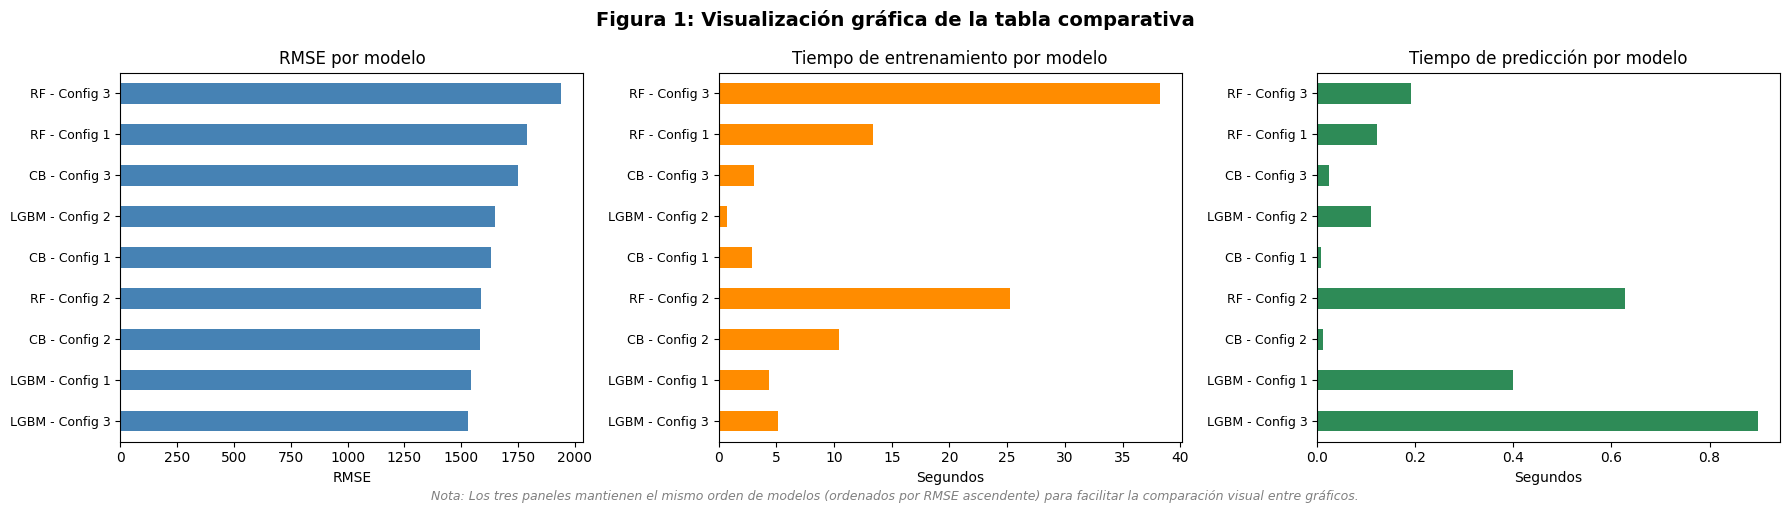

In [27]:
# Figura de tabla comparativa

# Acortar etiquetas para el gráfico usando abreviaciones
etiquetas_cortas = {
    'Random Forest - Config 1 (base)': 'RF - Config 1',
    'Random Forest - Config 2 (más profundo)': 'RF - Config 2',
    'Random Forest - Config 3 (más árboles, menos profundidad)': 'RF - Config 3',
    'LightGBM - Config 1 (base)': 'LGBM - Config 1',
    'LightGBM - Config 2 (más simple, rápida)': 'LGBM - Config 2',
    'LightGBM - Config 3 (más compleja, regularizada)': 'LGBM - Config 3',
    'CatBoost - Config 1 (base)': 'CB - Config 1',
    'CatBoost - Config 2 (más iteraciones, tasa baja)': 'CB - Config 2',
    'CatBoost - Config 3 (regularizado)': 'CB - Config 3'
}


comparacion_grafico = comparacion_hiperparametros.rename(index=etiquetas_cortas)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

comparacion_grafico['RMSE'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('RMSE por modelo')
axes[0].set_xlabel('RMSE')
axes[0].tick_params(axis='y', labelsize=9)

comparacion_grafico['Tiempo de entrenamiento (s)'].plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Tiempo de entrenamiento por modelo')
axes[1].set_xlabel('Segundos')
axes[1].tick_params(axis='y', labelsize=9)

comparacion_grafico['Tiempo de predicción (s)'].plot(kind='barh', ax=axes[2], color='seagreen')
axes[2].set_title('Tiempo de predicción por modelo')
axes[2].set_xlabel('Segundos')
axes[2].tick_params(axis='y', labelsize=9)


plt.suptitle('Figura 1: Visualización gráfica de la tabla comparativa', fontsize=14, fontweight='bold')
fig.text(0.5, 0.00, 'Nota: Los tres paneles mantienen el mismo orden de modelos (ordenados por RMSE ascendente) para facilitar la comparación visual entre gráficos.',
          ha='center', fontsize=9, style='italic', color='gray',  wrap=True)
plt.tight_layout()
plt.show()

> **Observación: Entrenamiento y evaluación del modelo**

**División de datos**

Los datos se dividieron en conjuntos de entrenamiento (60%), validación (20%) y prueba (20%):

| Conjunto | Filas | Columnas |
|---|---|---|
| Entrenamiento | 164,725 | 10 |
| Validación | 54,909 | 10 |
| Prueba | 54,909 | 10 |

**Escalado de variables**

Se aplicó escalado `StandardScaler` a las variables numéricas de los tres conjuntos (entrenamiento, validación y prueba), ajustando el escalador únicamente con los datos de entrenamiento para evitar fuga de información. Este paso es necesario para la Regresión Lineal, modelo sensible a la magnitud de las variables, aunque no afecta a los modelos basados en árboles.

**Entrenamiento de modelos**

Se entrenaron cinco modelos base: **Regresión Lineal** (modelo de referencia), **Árbol de Decisión**, **Bosque Aleatorio**, **LightGBM** y **CatBoost**. De estos, se seleccionaron los tres modelos con mejor desempeño inicial **LightGBM, Random Forest y CatBoost** para realizar un ajuste de hiperparámetros, probando tres configuraciones distintas por modelo. Los resultados fueron los siguientes:

| Modelo | RMSE | Tiempo de entrenamiento (s) | Tiempo de predicción (s) |
|---|---|---|---|
| **LightGBM – Config 3 (más compleja, regularizada)** | **1529.57** | **4.33** | **0.79** |
| LightGBM – Config 1 (base) | 1542.04 | 1.91 | 0.36 |
| **CatBoost – Config 2 (más iteraciones, tasa baja)** | **1581.05** | **9.78** | **0.01** |
| Random Forest – Config 2 (más profundo) | 1586.49 | 25.08 | 0.59 |
| CatBoost – Config 1 (base) | 1631.01 | 2.40 | 0.01 |
| LightGBM – Config 2 (más simple, rápida) | 1647.73 | 0.60 | 0.11 |
| CatBoost – Config 3 (regularizado) | 1750.73 | 3.00 | 0.02 |
| Random Forest – Config 1 (base) | 1788.82 | 10.22 | 0.10 |
| Random Forest – Config 3 (más árboles, menos profundidad) | 1940.61 | 27.73 | 0.19 |

**Interpretación**

Aunque **LightGBM Config 3** obtuvo el menor RECM (1529.57), su tiempo de predicción (0.79s) es notablemente más alto que el de otras configuraciones con RECM similar, lo que resulta menos ideal para una aplicación que necesita responder en tiempo real. **CatBoost Config 2** alcanza un RECM muy cercano (1581.05, solo ~3.4% mayor) con un tiempo de predicción prácticamente instantáneo (0.01s), casi 79 veces más rápido que LightGBM Config 3, lo que representa un mejor equilibrio entre calidad y velocidad, el criterio más relevante dado el caso de uso de Rusty Bargain.

Por lo tanto, se recomienda **CatBoost Config 2** como modelo final.

---
# <span style='color:#1B3A6B;'> 7. SELECCIÓN DEL MEJOR MODELO Y PRUEBA FINAL </span>
---

Una vez identificado el modelo con el mejor equilibrio entre calidad y velocidad; en este caso **CatBoost Config 2**, se evalúa su desempeño final sobre el conjunto de prueba.

In [24]:
# Mejor modelo

print("""Se selecciona CatBoost Config 2 como modelo final, no por tener el menor RMSE,
sino por ofrecer el mejor equilibrio entre calidad (RMSE) y velocidad de predicción,
el criterio más relevante para una aplicación en tiempo real.""")

mejor_modelo_final = modelos_cb['Config 2 (más iteraciones, tasa baja)']

print()
print('Modelo final seleccionado: CatBoost Config 2')
print(f'RMSE (validación): {resultados_cb["Config 2 (más iteraciones, tasa baja)"]["RMSE"]:.2f}')
print(f'Tiempo de predicción (validación): {resultados_cb["Config 2 (más iteraciones, tasa baja)"]["Tiempo de predicción (s)"]:.4f}s')

Se selecciona CatBoost Config 2 como modelo final, no por tener el menor RMSE,
sino por ofrecer el mejor equilibrio entre calidad (RMSE) y velocidad de predicción,
el criterio más relevante para una aplicación en tiempo real.

Modelo final seleccionado: CatBoost Config 2
RMSE (validación): 1581.05
Tiempo de predicción (validación): 0.0118s


In [25]:
# Predicción sobre el conjunto de prueba

mejor_modelo_final = modelos_cb['Config 2 (más iteraciones, tasa baja)']

start_pred_test   = time.time()
predicciones_test = mejor_modelo_final.predict(features_test)
tiempo_prediccion_test = time.time() - start_pred_test

rmse_test = mean_squared_error(target_test, predicciones_test, squared=False)

print(f'RMSE en el conjunto de prueba : {rmse_test:.2f}')
print(f'Tiempo de predicción en prueba: {tiempo_prediccion_test:.4f}s')

RMSE en el conjunto de prueba : 1593.05
Tiempo de predicción en prueba: 0.0125s


In [26]:
# Prueba de cordura: comparación contra un modelo dummy

modelo_dummy = DummyRegressor(strategy= 'mean')
evaluar_modelo(
    'Modelo Dummy (referencia)',
    modelo_dummy,
    features_train, target_train,
    features_valid, target_valid
)

Modelo Dummy (referencia): RMSE= 4560.06 | Entrenamiento= 0.00s | Predicción= 0.0002s


DummyRegressor()

---
# 8. CONCLUSIONES 
---


**Calidad de la predicción**

Los modelos de potenciación de gradiente LightGBM y CatBoost superaron consistentemente en RMSE a los modelos base evaluados en la etapa inicial de entrenamiento: Regresión Lineal (RMSE: 2741.73), Árbol de Decisión (1896.20) y Bosque Aleatorio (1672.54), frente a LightGBM (1542.04) y CatBoost (1557.82) en sus configuraciones base. Esta diferencia de más de 1,000 puntos de RMSE entre la Regresión Lineal y los modelos de boosting, confirma la capacidad de estos últimos para capturar relaciones no lineales entre las características técnicas del vehículo y su precio de mercado, algo que un modelo lineal simplemente no puede modelar.

**Tiempo de entrenamiento**

La Regresión Lineal fue, por amplio margen, el modelo más rápido de entrenar (~0.03s), seguida del Árbol de Decisión. Los modelos de ensamble requirieron tiempos considerablemente mayores: Random Forest resultó el más costoso, alcanzando hasta ~25s en su configuración más profunda, mientras que LightGBM se mantuvo, en general, como una de las opciones más eficientes dentro de los modelos de boosting entre ~0.6s y ~4.3s según la configuración. Esta diferencia de casi 800 veces entre el modelo más rápido y el más lento ilustra el costo computacional real de ganar precisión mediante modelos más complejos.

**Velocidad de predicción**

Se observaron diferencias relevantes entre modelos: mientras que CatBoost logró tiempos de predicción prácticamente instantáneos en varias configuraciones (0.01s–0.04s), algunas configuraciones de LightGBM con mayor complejidad (más hojas o mayor profundidad) alcanzaron tiempos notablemente más altos (hasta ~0.79s). Esta diferencia es especialmente relevante para Rusty Bargain, dado que la aplicación necesita responder en tiempo real ante cada consulta de un usuario.

**Modelo Dummy de referencia**

Como punto de comparación, el modelo Dummy que predice siempre el valor promedio del precio obtuvo un RMSE de 4560.06; muy superior al de todos los modelos entrenados, confirmando que todos los modelos evaluados aportan una mejora sustancial frente a una predicción ingenua.

**Modelo recomendado**

Se seleccionó **CatBoost Config 2** como modelo final. Durante la fase de ajuste de hiperparámetros, sobre el conjunto de validación obtuvo un RMSE de **1581.05** con un tiempo de predicción de **0.01s**. Al evaluarlo posteriormente sobre el conjunto de prueba los datos nunca antes vistos por el modelo, se confirmó su buen desempeño con un RMSE de **1593.05** y un tiempo de predicción de **0.0125s**, resultados consistentes con los obtenidos en validación.

Aunque CatBoost Config 2 no fue la configuración con el RMSE más bajo entre todas las evaluadas, ese lugar lo ocupó LightGBM Config 3, con mayor costo en tiempo de predicción, CatBoost Config 2 ofrece el mejor equilibrio entre los tres criterios solicitados por Rusty Bargain: calidad de predicción competitiva, tiempo de predicción muy bajo (adecuado para uso en tiempo real) y tiempo de entrenamiento razonable.

**RECOMENDACIONES**

Como líneas de mejora futura, se sugiere:

- Explorar ingeniería de características adicional, como la antigüedad del vehículo derivada de `RegistrationYear`, o variables de interacción entre marca y modelo.
- Aplicar validación cruzada más exhaustiva (K-Fold) en lugar de una única partición de validación, para obtener estimaciones más robustas del RMSE.
- Ajustar de forma más fina los hiperparámetros del modelo seleccionado por ejemplo, mediante `RandomizedSearchCV` para intentar reducir aún más el RMSE sin comprometer significativamente la velocidad de predicción.